In [ ]:
import pandas as pd
import re
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows

def parse_to_excel(input_text, output_file='data.xlsx'):
    lines = input_text.strip().split('\n')
    lines = [line for line in lines if line.strip()]
    
    headers = re.split(r'\s+', lines[0].strip())
    
    units = [u.strip('()') for u in re.split(r'\s+', lines[1].strip())]
    
    columns = []
    for h, u in zip(headers, units):
        if u == 'Secs':
            columns.append('Time_s')
        elif u == 'A':
            resistor = h.replace('I(', '').replace(')', '')
            columns.append(f'I{resistor}_A')
        elif u == 'V':
            resistor = h.replace('V(', '').replace(')', '')
            columns.append(f'V{resistor}_V')
        else:
            columns.append(f'{h}_{u}')
    
    data = []
    for line in lines[2:]:
        values = re.split(r'\s+', line.strip())
        if len(values) == len(headers):
            data.append([float(v) for v in values])
    df = pd.DataFrame(data, columns=columns)
    df.to_excel(output_file, index=False)
    print(f'✅ Файл сохранен: {output_file}')
    print(f'   Строк: {len(df)}, Колонок: {len(df.columns)}')


In [21]:
parse_to_excel(
"""
T       I(R4)       I(R8)      I(R11)      I(R14)      I(R17)      I(R20)      I(R23)      I(R26)      I(R29)      I(R32)      I(R35)      I(R38)      I(R41)      I(R44)     I(R47)       V(R4)       V(R8)      V(R11)      V(R14)      V(R17)      V(R20)      V(R23)      V(R26)      V(R29)      V(R32)      V(R35)      V(R38)      V(R41)      V(R44)     V(R47)
      (Secs)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)        (A)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)        (V)
   5.745E-08   9.500E-03   1.157E-02   1.273E-02   1.295E-02   1.223E-02   1.068E-02   8.444E-03   5.702E-03   2.675E-03  -4.111E-04  -3.335E-03  -5.894E-03  -7.924E-03  -9.302E-03   9.958E-03   9.500E-09   1.157E-08   1.273E-08   1.295E-08   1.223E-08   1.068E-08   8.444E-09   5.702E-09   2.675E-09  -4.111E-10  -3.335E-09  -5.894E-09  -7.924E-09  -9.302E-09   9.958E-09
""", 
    output_file='load.xlsx'
)

✅ Файл сохранен: load.xlsx
   Строк: 1, Колонок: 31


In [22]:
parse_to_excel(
"""
T       I(R4)       I(R8)      I(R11)      I(R14)      I(R17)      I(R20)      I(R23)      I(R26)      I(R29)      I(R32)      I(R35)      I(R38)      I(R41)      I(R44)      I(R47)       V(R4)       V(R8)      V(R11)      V(R14)      V(R17)      V(R20)      V(R23)      V(R26)      V(R29)      V(R32)      V(R35)      V(R38)      V(R41)      V(R44)      V(R47)
      (Secs)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)
   6.879E-08  -9.569E-03  -9.109E-03  -8.170E-03  -6.828E-03  -5.173E-03  -3.304E-03  -1.325E-03   6.618E-04   2.561E-03   4.285E-03   5.758E-03   6.919E-03   7.719E-03   8.127E-03  -8.127E-03  -9.569E-09  -9.109E-09  -8.170E-09  -6.828E-09  -5.173E-09  -3.304E-09  -1.325E-09   6.618E-10   2.561E-09   4.285E-09   5.758E-09   6.919E-09   7.719E-09   8.127E-09  -8.127E-09
""", 
    output_file='kz.xlsx'
)

✅ Файл сохранен: kz.xlsx
   Строк: 1, Колонок: 31


In [20]:
parse_to_excel(
"""
T       I(R4)       I(R8)      I(R11)      I(R14)      I(R17)      I(R20)      I(R23)      I(R26)      I(R29)      I(R32)      I(R35)      I(R38)      I(R41)      I(R44)      I(R47)       V(R4)       V(R8)      V(R11)      V(R14)      V(R17)      V(R20)      V(R23)      V(R26)      V(R29)      V(R32)      V(R35)      V(R38)      V(R41)      V(R44)      V(R47)
      (Secs)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (A)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)         (V)
   9.653E-08  -1.115E-02  -5.689E-03   8.504E-05   5.785E-03   1.103E-02   1.549E-02   1.886E-02   2.094E-02   2.159E-02   2.079E-02   1.859E-02   1.514E-02   1.069E-02   5.530E-03  0.000E+00  -1.115E-08  -5.689E-09   8.504E-11   5.785E-09   1.103E-08   1.549E-08   1.886E-08   2.094E-08   2.159E-08   2.079E-08   1.859E-08   1.514E-08   1.069E-08   5.530E-09  0.000E+00
""", 
    output_file='hh.xlsx'
)

✅ Файл сохранен: hh.xlsx
   Строк: 1, Колонок: 31


In [9]:
import matplotlib.pyplot as plt
import numpy as np


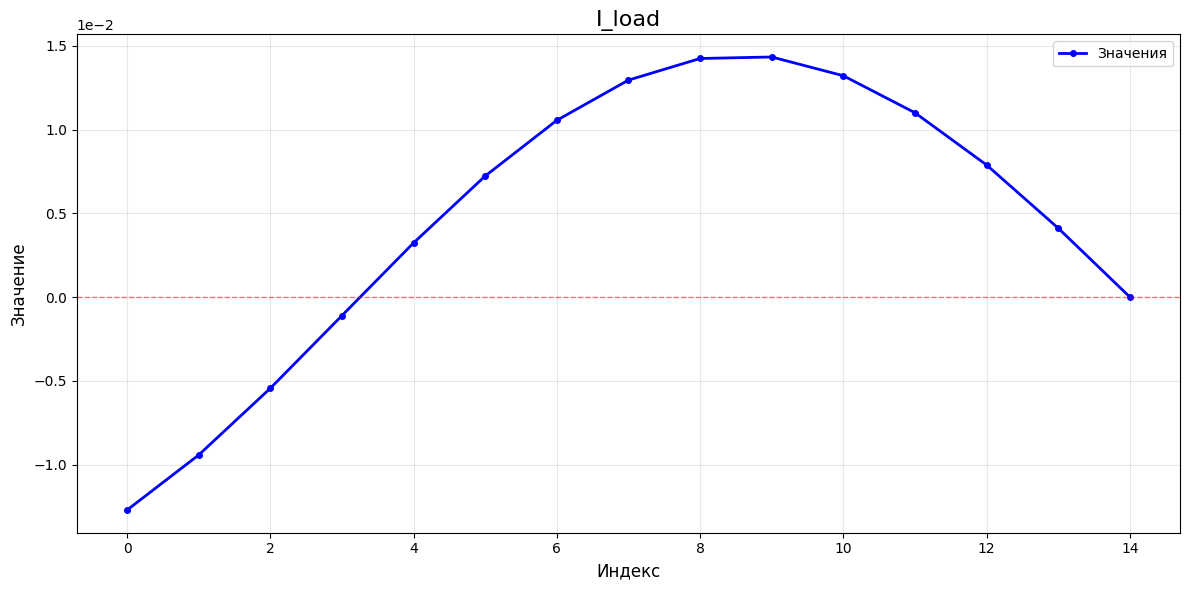

Всего значений: 15
Минимальное значение: -1.272000e-02
Максимальное значение: 1.433000e-02


In [ ]:


input_string = "-0,01272	-0,009432	-0,00545	-0,00111	0,003231	0,007224	0,01055	0,01295	0,01424	0,01433	0,01321	0,011	0,007882	0,00411	0"
input_string = input_string.replace(",", ".")




numbers = [float(x) for x in input_string.split()]


x_indices = list(range(len(numbers)))


plt.figure(figsize=(12, 6))
plt.plot(x_indices, numbers, 'b-o', linewidth=2, markersize=4, label='Значения')


plt.title('I_load', fontsize=16)
plt.xlabel('Индекс', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()


plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1)


plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


plt.tight_layout()
plt.show()


print(f"Всего значений: {len(numbers)}")
print(f"Минимальное значение: {min(numbers):.6e}")
print(f"Максимальное значение: {max(numbers):.6e}")

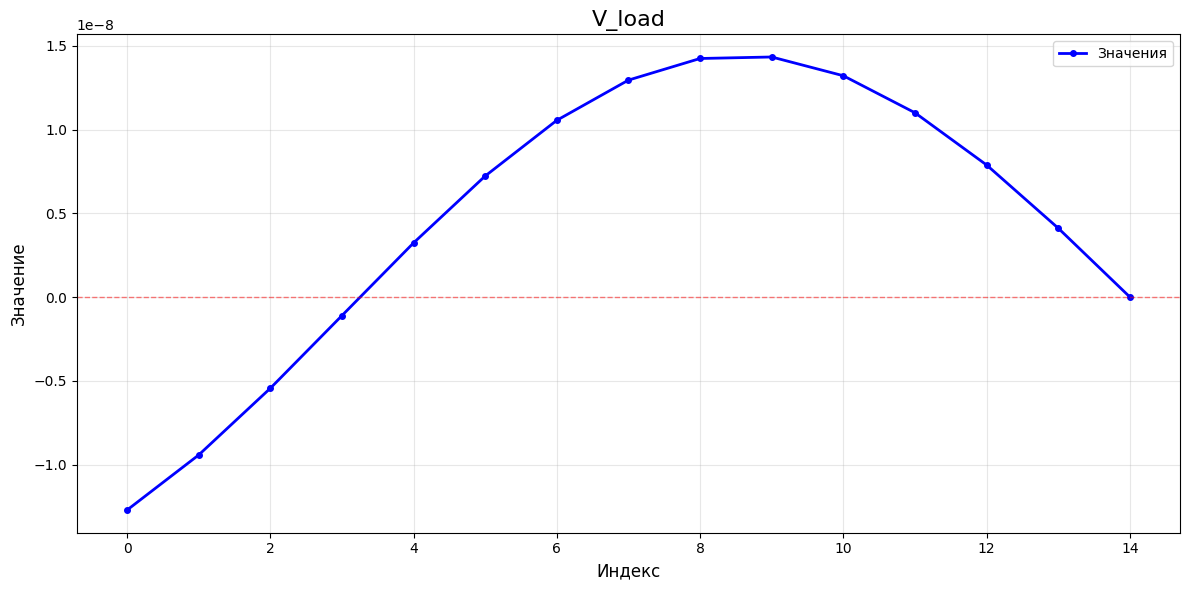

Всего значений: 15
Минимальное значение: -1.272000e-08
Максимальное значение: 1.433000e-08


In [ ]:


input_string = "-1,272E-08	-9,432E-09	-5,45E-09	-1,11E-09	3,231E-09	7,224E-09	1,055E-08	1,295E-08	1,424E-08	1,433E-08	1,321E-08	0,000000011	7,882E-09	4,11E-09	0"
input_string = input_string.replace(",", ".")




numbers = [float(x) for x in input_string.split()]


x_indices = list(range(len(numbers)))


plt.figure(figsize=(12, 6))
plt.plot(x_indices, numbers, 'b-o', linewidth=2, markersize=4, label='Значения')


plt.title('V_load', fontsize=16)
plt.xlabel('Индекс', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()


plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1)


plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


plt.tight_layout()
plt.show()


print(f"Всего значений: {len(numbers)}")
print(f"Минимальное значение: {min(numbers):.6e}")
print(f"Максимальное значение: {max(numbers):.6e}")

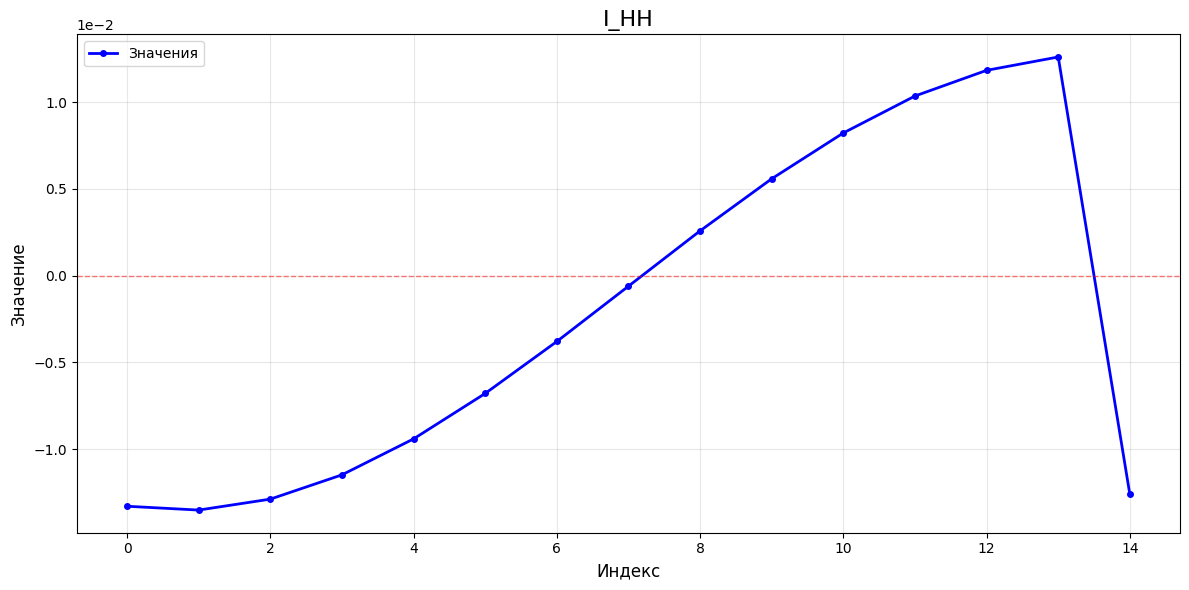

Всего значений: 15
Минимальное значение: -1.351000e-02
Максимальное значение: 1.261000e-02


In [ ]:


input_string = "-0,01329	-0,01351	-0,01288	-0,01148	-0,009407	-0,006787	-0,003792	-0,0006034	0,002586	0,005589	0,00823	0,01036	0,01184	0,01261	-0,01261"
input_string = input_string.replace(",", ".")




numbers = [float(x) for x in input_string.split()]


x_indices = list(range(len(numbers)))


plt.figure(figsize=(12, 6))
plt.plot(x_indices, numbers, 'b-o', linewidth=2, markersize=4, label='Значения')


plt.title('I_HH', fontsize=16)
plt.xlabel('Индекс', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()


plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1)


plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


plt.tight_layout()
plt.show()


print(f"Всего значений: {len(numbers)}")
print(f"Минимальное значение: {min(numbers):.6e}")
print(f"Максимальное значение: {max(numbers):.6e}")

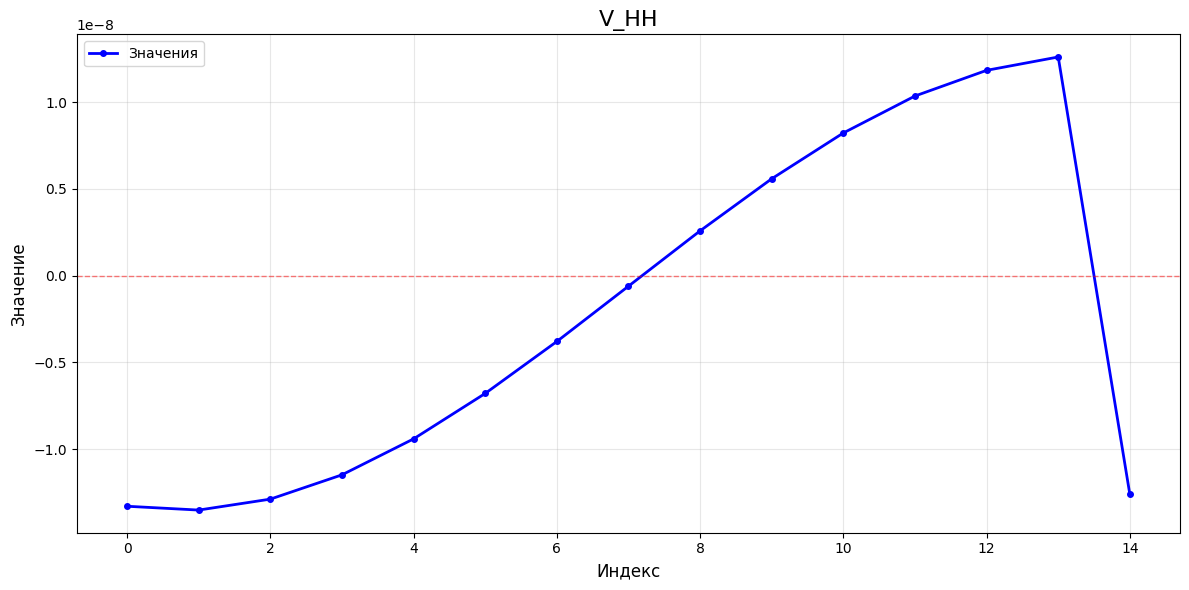

Всего значений: 15
Минимальное значение: -1.351000e-08
Максимальное значение: 1.261000e-08


In [ ]:


input_string = "-1,329E-08	-1,351E-08	-1,288E-08	-1,148E-08	-9,407E-09	-6,787E-09	-3,792E-09	-6,034E-10	2,586E-09	5,589E-09	8,23E-09	1,036E-08	1,184E-08	1,261E-08	-1,261E-08"
input_string = input_string.replace(",", ".")




numbers = [float(x) for x in input_string.split()]


x_indices = list(range(len(numbers)))


plt.figure(figsize=(12, 6))
plt.plot(x_indices, numbers, 'b-o', linewidth=2, markersize=4, label='Значения')


plt.title('V_HH', fontsize=16)
plt.xlabel('Индекс', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()


plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1)


plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


plt.tight_layout()
plt.show()


print(f"Всего значений: {len(numbers)}")
print(f"Минимальное значение: {min(numbers):.6e}")
print(f"Максимальное значение: {max(numbers):.6e}")

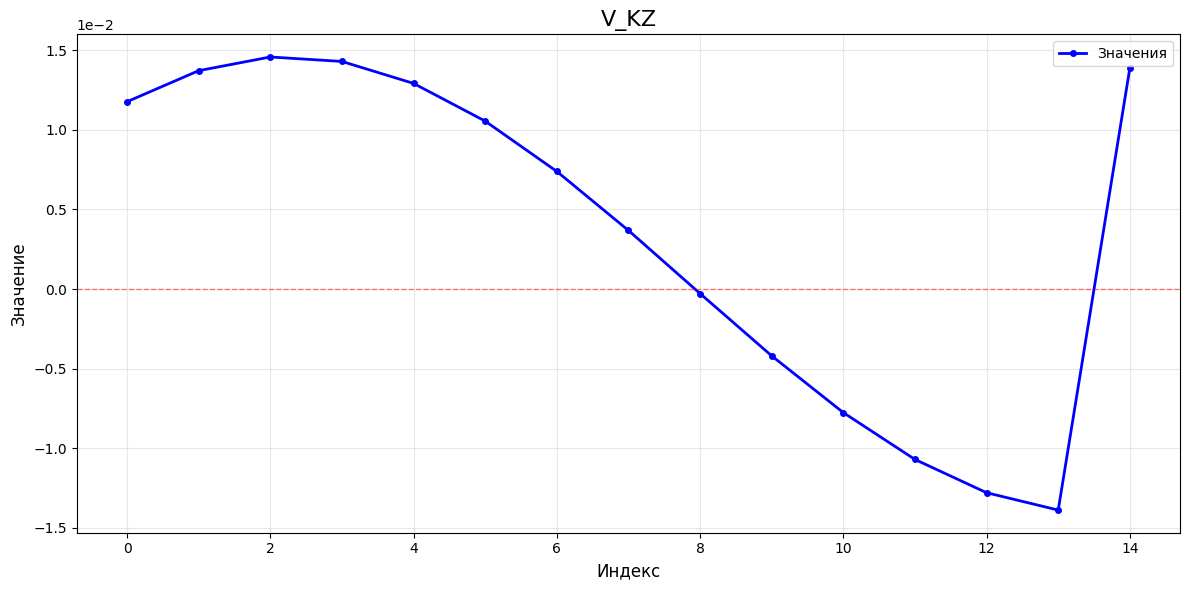

Всего значений: 15
Минимальное значение: -1.389000e-02
Максимальное значение: 1.458000e-02


In [ ]:


input_string = "0,01177	0,01372	0,01458	0,0143	0,01292	0,01055	0,007389	0,003681	-0,0002846	-0,0042	-0,007766	-0,01071	-0,0128	-0,01389	0,01389"
input_string = input_string.replace(",", ".")




numbers = [float(x) for x in input_string.split()]


x_indices = list(range(len(numbers)))


plt.figure(figsize=(12, 6))
plt.plot(x_indices, numbers, 'b-o', linewidth=2, markersize=4, label='Значения')


plt.title('I_KZ', fontsize=16)
plt.xlabel('Индекс', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()


plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1)


plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


plt.tight_layout()
plt.show()


print(f"Всего значений: {len(numbers)}")
print(f"Минимальное значение: {min(numbers):.6e}")
print(f"Максимальное значение: {max(numbers):.6e}")

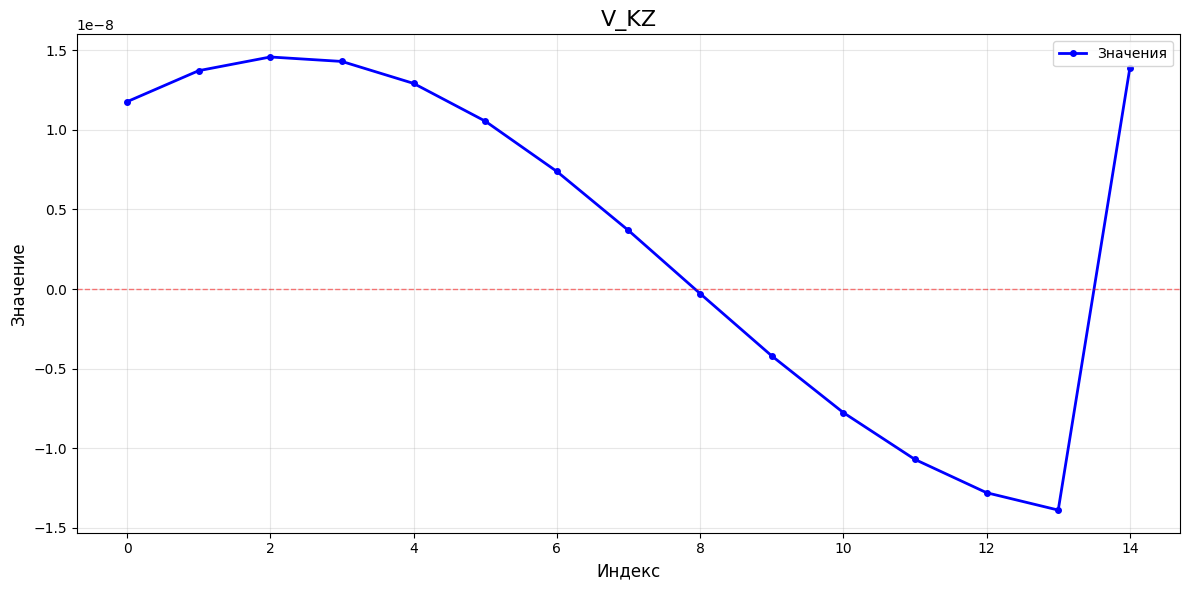

Всего значений: 15
Минимальное значение: -1.389000e-08
Максимальное значение: 1.458000e-08


In [ ]:


input_string = "1,177E-08	1,372E-08	1,458E-08	1,43E-08	1,292E-08	1,055E-08	7,389E-09	3,681E-09	-2,846E-10	-4,2E-09	-7,766E-09	-1,071E-08	-1,28E-08	-1,389E-08	1,389E-08"
input_string = input_string.replace(",", ".")




numbers = [float(x) for x in input_string.split()]


x_indices = list(range(len(numbers)))


plt.figure(figsize=(12, 6))
plt.plot(x_indices, numbers, 'b-o', linewidth=2, markersize=4, label='Значения')


plt.title('V_KZ', fontsize=16)
plt.xlabel('Индекс', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()


plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1)


plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


plt.tight_layout()
plt.show()


print(f"Всего значений: {len(numbers)}")
print(f"Минимальное значение: {min(numbers):.6e}")
print(f"Максимальное значение: {max(numbers):.6e}")